In [2]:
import os, re
import argparse

import numpy as np
import pandas as pd
import lightkurve as lk

from tess_asteroid_ml import *
from tess_asteroid_ml.make_TESS_asteroid_db import *
from tess_asteroid_ml.utils import in_cutout, power_find
from tess_asteroid_ml.make_TESScut_asteroids import *

import warnings
warnings.simplefilter('ignore')

/Users/jorgemarpa/.pyenv/versions/tess-test/lib/python3.9/site-packages/lightkurve/config/__init__.py:119: UserWarning: The default Lightkurve cache directory, used by download(), etc., has been moved to /Users/jorgemarpa/.lightkurve/cache. Please move all the files in the legacy directory /Users/jorgemarpa/.lightkurve-cache to the new location and remove the legacy directory. Refer to https://docs.lightkurve.org/reference/config.html#default-cache-directory-migration for more information.
  warnings.warn(


In [3]:
sector = 20
camera = 3
ccd = 3
sampling = "sparse"
fit_bkg = True
limiting_mag = 22
cutout_size = 64
verbose = True
plot = False
download=False

In [4]:
provider = "mast"

# get FFI image
ffi_file = get_FFI_name(
    sector=sector, camera=camera, ccd=ccd, provider=provider, correct=False
)
if verbose:
    print(f"Working on FFI sector {sector} camera {camera} ccd {ccd}")
    print(f"FFI file is {ffi_file[0]}")

# get FFI data to build ra/dec coordinates for later query
ffi_header, f2d, col_2d, row_2d, ra_2d, dec_2d = get_data_from_files(
    ffi_file, provider=provider
)
ffi_header = ffi_header[0]
f2d = f2d[0]
col_2d = col_2d
row_2d = row_2d
ra_2d = ra_2d[0]
dec_2d = dec_2d[0]

obs_time = Time([ffi_header["DATE-OBS"], ffi_header["DATE-END"]], format="isot")

# get asteroid catalog
jpl_df = get_asteroid_table(
    SkyCoord(ra_2d.min() * u.deg, dec_2d.min() * u.deg, frame='icrs'),
    SkyCoord(ra_2d.max() * u.deg, dec_2d.max() * u.deg, frame='icrs'),
    sector=sector,
    camera=camera,
    ccd=0,
    date_obs=obs_time.mean().jd,
)
if limiting_mag <= 30:
    asteroid_df = jpl_df.query(f"V_mag <= {limiting_mag}")
if verbose:
    print(f"Asteroid table has {len(asteroid_df)} items with V < {limiting_mag}")

# get asteroid tracks in low res
sb_ephems_lowres = read_asteroid_db(
    asteroid_df.head(5000), low_res=True, sector=sector, camera=camera, ccd=ccd
)
if verbose:
    print(f"Asteroid track DB has {len(sb_ephems_lowres)} available")

Working on FFI sector 20 camera 3 ccd 3
FFI file is https://archive.stsci.edu/missions/tess/ffi/s0020/2020/007/3-3/tess2020007215923-s0020-3-3-0165-s_ffic.fits
Loading from CSV file: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/jpl/jpl_small_bodies_tess_s0020-3-0_catalog.csv
JPL SBI found 265 asteroids with V < 30 in s0020-3-0
Asteroid table has 123 items with V < 22


Asteroid track DB has 93 available


In [11]:
# get cutout centers given size and overlap
xcen, ycen = get_cutout_centers(sampling="tiled", overlap=5, size=cutout_size)
# create a dict with cutout centers in radec
cut_dict = {}
for i in ycen[1:, 0]:
    for j in xcen[0, 1:]:
        cut_dict[f"c{col_2d[i, j]:04}_r{row_2d[i,j]:04}"] = SkyCoord(
            ra_2d[i, j] * u.deg, dec_2d[i, j] * u.deg, frame="icrs"
        )
# cut_dict

In [15]:
tpf_names_list = get_ffi_cutouts(
    coords=cut_dict,
    sampling=sampling,
    download=True,
    sector=sector,
    cam_ccd=f"{camera}-{ccd}",
    cutout_size=cutout_size,
)
if np.max([len(x) for x in tpf_names_list]) == 0:
    print("WARNING: No cutout TPFs available in disk. Please run again with "
          "`--download` flag to get the data")

Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0020/TESScut_s0020-3-3_c0137_r1509_64x64pix.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0020/TESScut_s0020-3-3_c0196_r1509_64x64pix.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0020/TESScut_s0020-3-3_c0255_r1509_64x64pix.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0020/TESScut_s0020-3-3_c0314_r1509_64x64pix.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0020/TESScut_s0020-3-3_c0373_r1509_64x64pix.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0020/TESScut_s0020-3-3_c0432_r1509_64x64pix.fits
Creating FFI cut: /Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0020/TESScut_s0020-3-3_c0491_r1509_64x64pix.fits
Creating FFI cut: /Users/jorgemarp

In [16]:
for nn, tpf_names in enumerate(tpf_names_list):
    if len(tpf_names) == 0:
        continue
    nrow = np.unique(
        [int(re.findall(r"\_c(\d+)\_r(\d+)\_", string=x)[0][1]) for x in tpf_names]
    )[0]
    if verbose:
        print(
            f"Working with FFI row {nn + 1}/{len(tpf_names_list)} "
            f"and {len(tpf_names)} cuts..."
        )
    # iterate cutouts in a single row
    F, X, Y, L, NAMES, CAD = [], [], [], [], [], []
    sb_ephems_highres = {}
    for q, ff in tqdm(
        enumerate(tpf_names),
        total=len(tpf_names),
        desc=f"TESS cut files row {nrow + 1}",
    ):
        fficut_aster = AsteroidTESScut(lk.read(ff, quality_bitmask=None))
        fficut_aster.ffi_exp_time = (
            (ffi_header["TSTOP"] - ffi_header["TSTART"]) * 24 * 3600
        )
        if fit_bkg:
            fficut_aster.fit_background(polyorder=3, positive_flux=True)

        c = 0
        for k, val in sb_ephems_lowres.items():
            if len(val) == 0:
                continue
            # check if asteroid track passes over the TESScut
            is_in = in_cutout(
                fficut_aster.column,
                fficut_aster.row,
                sb_ephems_lowres[k].column.values,
                sb_ephems_lowres[k].row.values,
            )
            if is_in:
                if k not in sb_ephems_highres.keys():
                    sb_ephems_highres.update(
                        read_asteroid_db(
                            asteroid_df.loc[[k]],
                            low_res=False,
                            sector=sector,
                            camera=camera,
                            ccd=ccd,
                            quiet=True,
                        )
                    )
                source_rad = 3.2e2 / (sb_ephems_highres[k].vmag.mean()) ** 1.8
                fficut_aster.get_asteroid_mask(
                    sb_ephems_highres[k],
                    name=asteroid_df.loc[k, ["Object name", "V_mag"]],
                    mask_type="circular",
                    mask_radius=source_rad,
                    mask_num_type="dec",
                )
            c += 1
            if c > 20: break
        F.append(fficut_aster.flux_2d)
        X.append(fficut_aster.column_2d[0, 0])
        Y.append(fficut_aster.row_2d[0, 0])
        L.append(fficut_aster.asteroid_mask_2d)
        CAD.append(fficut_aster.cadenceno[fficut_aster.quality_mask])
        if hasattr(fficut_aster, "asteroid_names"):
            NAMES.append(
                pd.DataFrame.from_dict(fficut_aster.asteroid_names, orient="index")
            )
        else:
            NAMES.append(pd.DataFrame([]))

        if fficut_aster.asteroid_mask_2d is None:
            break
        # print(fficut_aster.flux.shape, fficut_aster.time.shape, fficut_aster.cbvs.shape)
        # if q == 32:
        #     break

    keep_cad = reduce(np.intersect1d, CAD)
    keep_mask = [np.isin(C, keep_cad) for C in CAD]

    # make 4d arrays (n_cutout, n_time, n_col, n_row)
    F = np.array([F[k][keep_mask[k]] for k in range(len(F))])
    L = np.array([L[k][keep_mask[k]] for k in range(len(L))])
    
    X, Y = np.array(X), np.array(Y)

    # make others arrays, time, CBV, quat and angles
    keep_mask = np.isin(fficut_aster.cadenceno[fficut_aster.quality_mask], keep_cad)
    TIME = fficut_aster.time[keep_mask]
    
    fficut_aster.get_CBVs(align=False, interpolate=True)
    CBV = fficut_aster.cbvs[keep_mask]
    
    ff = (
        f"{os.path.dirname(PACKAGEDIR)}/data/engineering/TESSVectors_S1-26_FFI"
        f"/TessVectors_S{sector:03}_C{camera}_FFI.csv"
    )
    vectors = pd.read_csv(ff, skiprows=44)
    QUAT = vectors.loc[keep_cad, ["Quat1_Med", "Quat2_Med", "Quat3_Med", "Quat4_Med"]].values
    E_ANG = vectors.loc[keep_cad, ["Earth_Camera_Angle", "Earth_Camera_Azimuth"]].values
    M_ANG = vectors.loc[keep_cad, ["Moon_Camera_Angle", "Moon_Camera_Azimuth"]].values
    break

Working with FFI row 25/33 and 33 cuts...


TESS cut files row 1510: 100%|████████████████████████████████████████████████████| 33/33 [01:51<00:00,  3.38s/it]


In [39]:
TIME[~np.isfinite(QUAT[:, 0])].shape

(11,)

In [56]:
df = pd.DataFrame(QUAT, index=TIME)
df

,0,1,2,3
2.458843e+06,-2.010973e-06,1.754893e-06,-1.186502e-06,1.0
2.458843e+06,-2.045218e-06,1.866842e-06,-1.127421e-06,1.0
2.458843e+06,-2.097480e-06,1.775162e-06,-1.420466e-06,1.0
2.458843e+06,-2.255334e-06,1.696892e-06,-1.270256e-06,1.0
2.458843e+06,-2.032290e-06,1.625363e-06,-1.183748e-06,1.0
...,...,...,...,...
2.458869e+06,5.106080e-07,-5.578046e-08,9.286971e-07,1.0
2.458869e+06,5.600234e-07,4.231717e-08,9.643747e-07,1.0
2.458869e+06,5.498303e-07,3.447611e-08,1.068278e-06,1.0
2.458869e+06,6.873394e-07,-7.012730e-08,9.430067e-07,1.0


In [88]:
df_inter = pd.DataFrame(QUAT, index=TIME).interpolate(method="slinear", axis=0).values

In [5]:
np.sum([1,2])

3

0


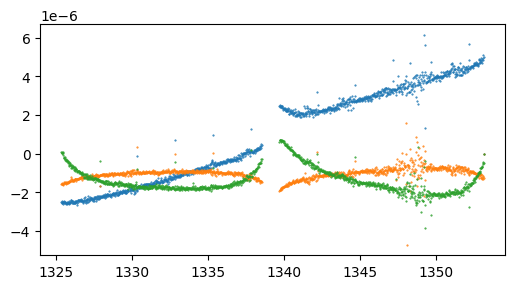

0


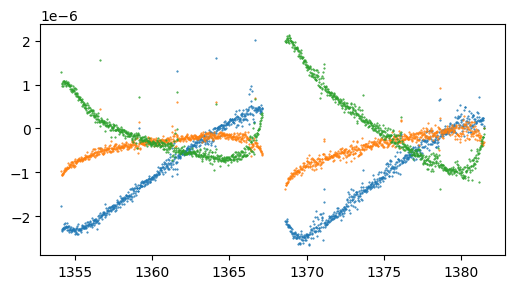

0


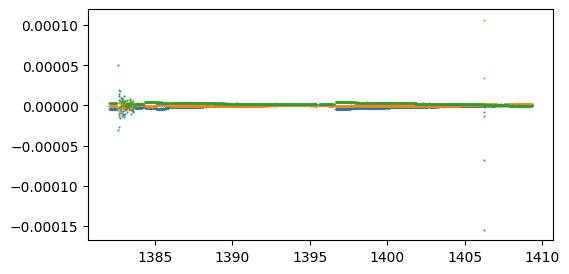

0


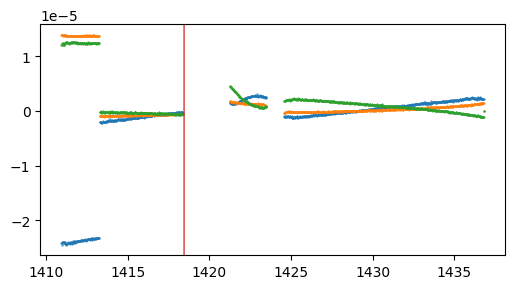

0


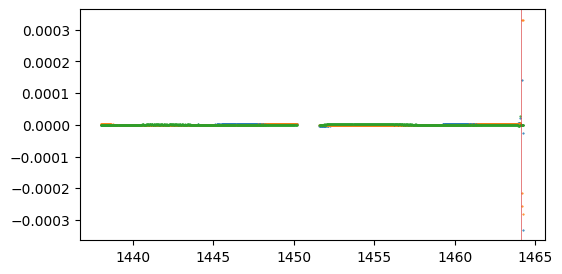

0


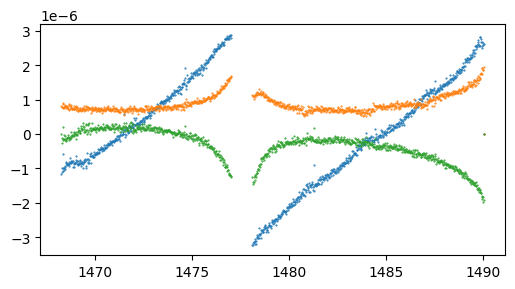

0


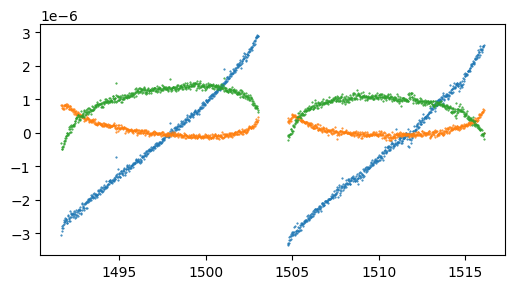

0


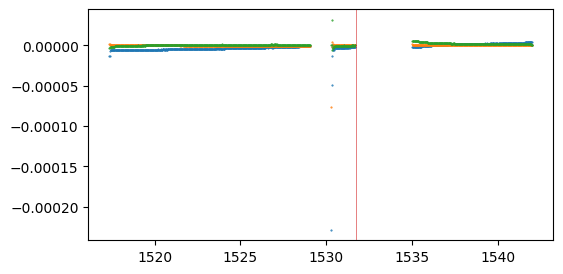

0


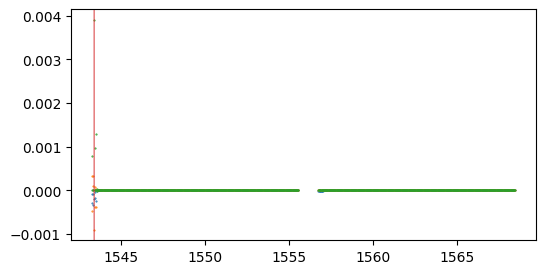

0


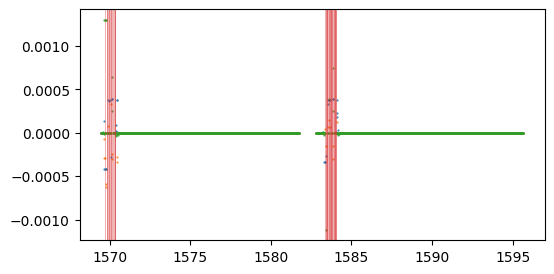

0


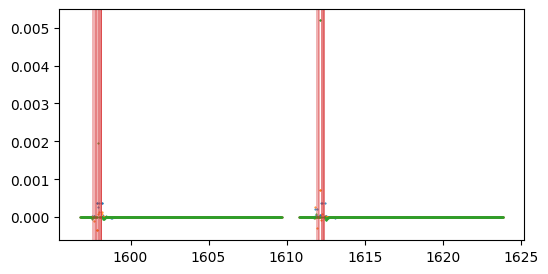

0


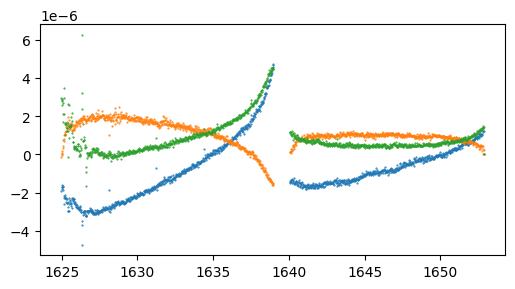

0


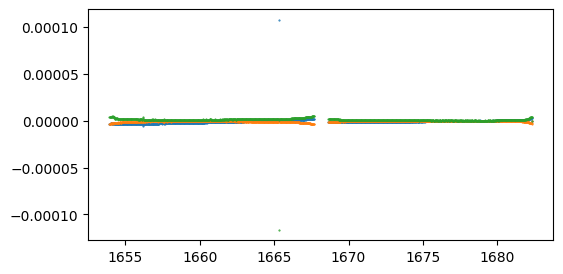

0


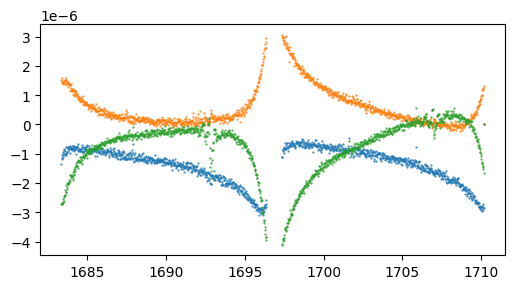

0


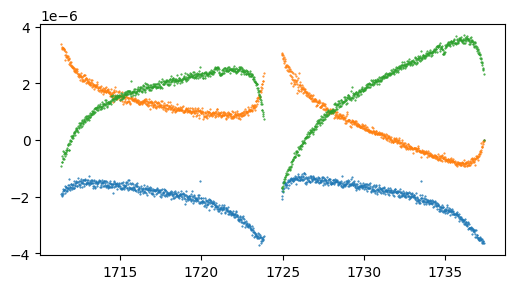

0


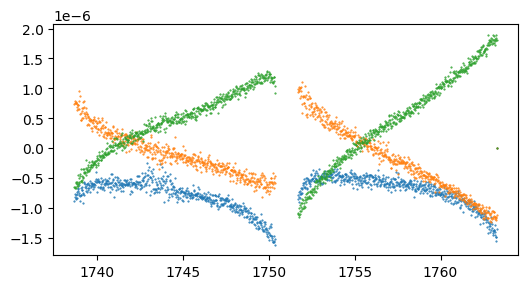

0


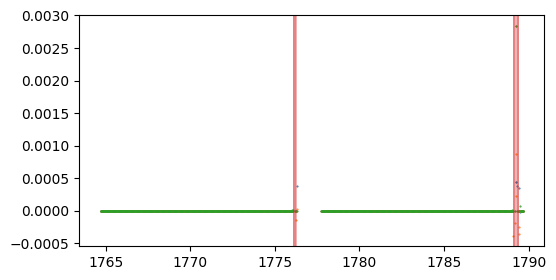

0


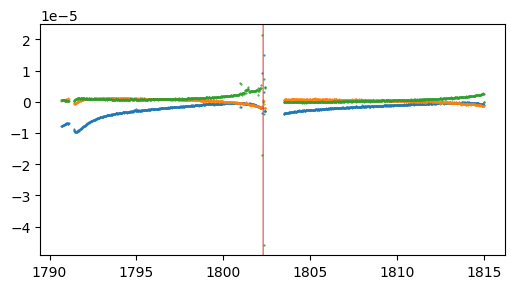

0


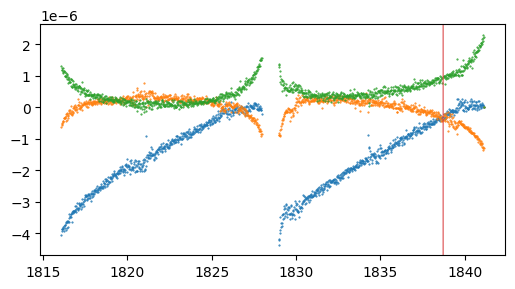

0


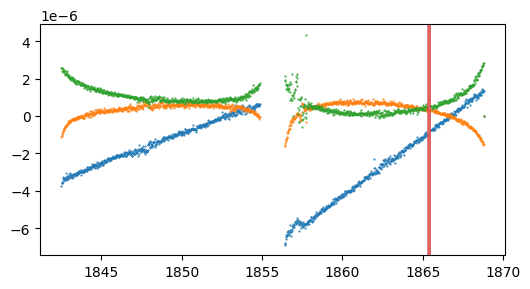

0


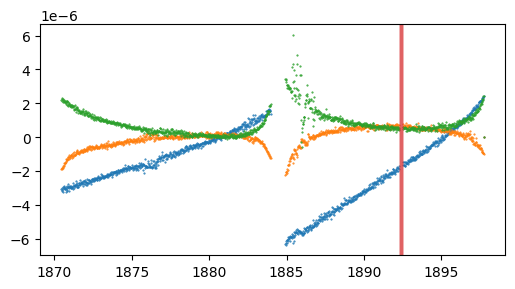

0


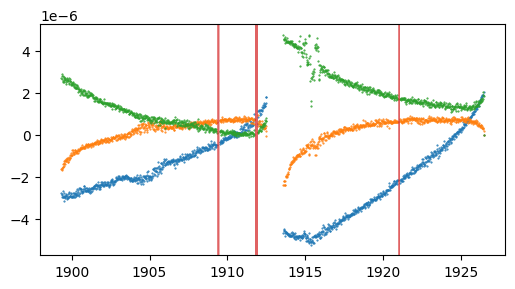

0


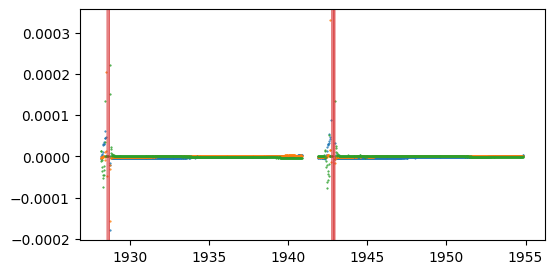

0


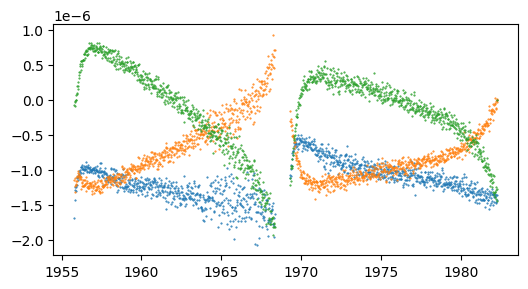

0


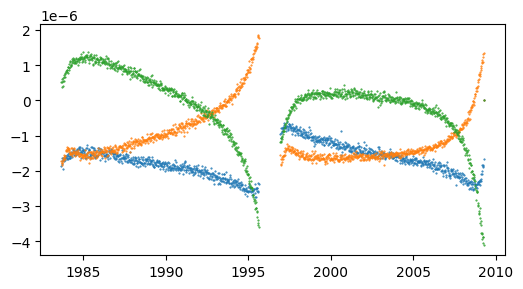

In [4]:
for sec in range(1,26):
    ff = (
            f"{os.path.dirname(PACKAGEDIR)}/data/engineering/TESSVectors_S1-26_FFI"
            f"/TessVectors_S{sec:03}_C{1}_FFI.csv"
        )
    vectors = pd.read_csv(ff, skiprows=44)
    nans_all = ((~np.isfinite(vectors.loc[:, "Quat1_Med"])) & 
                (~np.isfinite(vectors.loc[:, "Earth_Camera_Angle"])))
    print(nans_all.sum())   
    plt.figure(figsize=(6,3))
    plt.plot(vectors.MidTime, vectors.loc[:, ["Quat1_Med", "Quat2_Med", "Quat3_Med"]], ".", ms=1)
    for x in vectors.MidTime[~np.isfinite(vectors.loc[:, "Quat1_Med"])]:
        plt.axvline(x, c="tab:red", lw=.5, alpha=.5)
    plt.show()

    # break

In [102]:
vectors

,Cadence,MidTime,TimeCorr,Segment,Quat_Start,Quat_Stop,Quat_MIN_FOM,Quat_MIN_NUM_GSUSED,Quat_NBinned,Quat1_Med,...,Quat4_Med,Quat4_StdDev,Quat4_StdDev_SigClip,Earth_Distance,Earth_Camera_Angle,Earth_Camera_Azimuth,Moon_Distance,Moon_Camera_Angle,Moon_Camera_Azimuth,FFIFile
0,0.0,1983.659607,0.003077,1.0,1983.646133,1983.666920,224.0,198.0,899.0,-0.000002,...,1.0,7.021559e-12,5.001029e-12,21.752974,66.787505,299.738353,52.178415,70.809329,57.802426,tess2020135032918-s0025-1-1-0182-s_ffi
1,1.0,1983.680481,0.003078,1.0,1983.667012,1983.687799,224.0,199.0,899.0,-0.000002,...,1.0,9.912618e-11,8.219581e-12,22.105913,65.711955,300.481180,52.413479,70.525898,57.757084,tess2020135035918-s0025-1-1-0182-s_ffi
2,2.0,1983.701294,0.003078,1.0,1983.687822,1983.708609,224.0,198.0,899.0,-0.000002,...,1.0,7.677673e-12,5.566979e-12,22.413966,64.801480,301.121893,52.621483,70.285156,57.726060,tess2020135042918-s0025-1-1-0182-s_ffi
3,3.0,1983.722107,0.003079,1.0,1983.708633,1983.729420,224.0,199.0,899.0,-0.000002,...,1.0,9.214824e-12,5.611768e-12,22.743120,63.856288,301.799381,52.846423,70.034605,57.701427,tess2020135045918-s0025-1-1-0182-s_ffi
4,4.0,1983.742981,0.003079,1.0,1983.729512,1983.750299,224.0,198.0,899.0,-0.000002,...,1.0,1.133926e-11,6.182858e-12,23.071245,62.941111,302.468127,53.073207,69.791554,57.685352,tess2020135052918-s0025-1-1-0182-s_ffi
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1164,1164.0,2009.201599,0.003363,2.0,2009.187834,2009.208621,224.0,199.0,899.0,-0.000002,...,1.0,1.670026e-11,1.273908e-11,12.168787,141.578763,147.551971,57.072388,75.800155,63.793008,tess2020160162917-s0025-1-1-0182-s_ffi
1165,1165.0,2009.222412,0.003363,2.0,2009.208644,2009.229454,224.0,199.0,900.0,-0.000002,...,1.0,5.483416e-11,1.367291e-11,11.909198,143.705922,152.057790,56.536154,75.882403,63.510379,tess2020160165917-s0025-1-1-0182-s_ffi
1166,1166.0,2009.243225,0.003363,2.0,2009.229478,2009.250265,224.0,198.0,899.0,-0.000002,...,1.0,1.767558e-11,1.195994e-11,11.647835,145.864276,157.645810,55.968158,75.945782,63.180941,tess2020160172917-s0025-1-1-0182-s_ffi
1167,1167.0,2009.264099,0.003363,2.0,2009.250334,2009.271121,224.0,198.0,899.0,-0.000002,...,1.0,3.390948e-11,1.291066e-11,11.390382,147.937021,164.600257,55.372784,75.982663,62.798578,tess2020160175917-s0025-1-1-0182-s_ffi


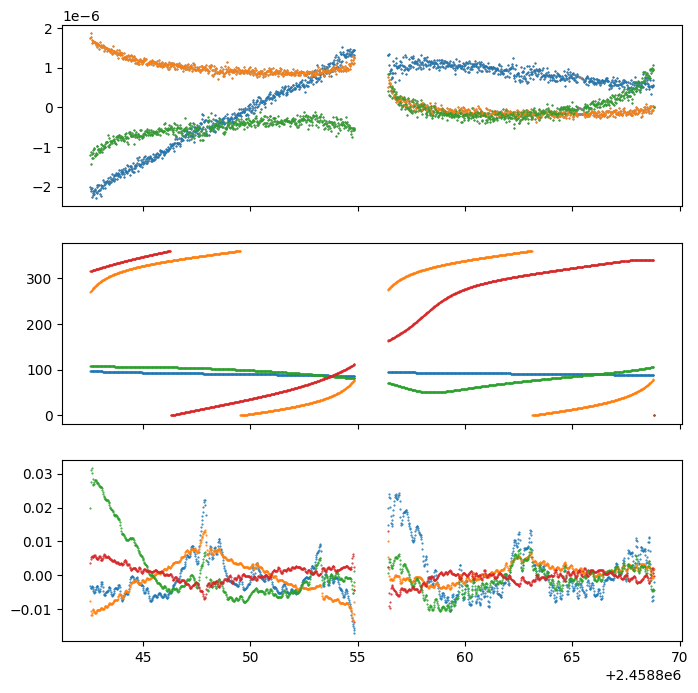

In [89]:
fig, ax = plt.subplots(3,1,sharex=True, figsize=(8, 8))
ax[0].plot(TIME, df_inter[:, :3], ".", ms=1, c="gray")
ax[0].plot(TIME, QUAT[:, :3], ".", ms=1)
# for x in TIME[~np.isfinite(QUAT[:, 0])]:
#     ax[0].axvline(x, c="tab:red", lw=1)
ax[1].plot(TIME, E_ANG, ".", ms=1)
ax[1].plot(TIME, M_ANG, ".", ms=1)
ax[2].plot(TIME, CBV[:, :4], ".", ms=1)
plt.show()

In [258]:
fficut_aster.flux.shape

(1099, 4096)

In [260]:
cbvs = lk.correctors.load_tess_cbvs(
            sector=sector,
            camera=camera,
            ccd=ccd,
            cbv_type="MultiScale",
            band=2,
        )
cbvs

time,CADENCENO,GAP,VECTOR_1,VECTOR_2,VECTOR_3,VECTOR_4,VECTOR_5,VECTOR_6,VECTOR_7,VECTOR_8
,,,,,,,,,,
Time,int32,bool,float32,float32,float32,float32,float32,float32,float32,float32
1569.4317289514056,246223,0,0.00052,0.00080,-0.00052,-0.00086,-0.00122,-0.00063,0.00157,0.00049
...,...,...,...,...,...,...,...,...,...,...
1595.6803288758229,265122,0,-0.00222,0.00319,-0.00493,0.00189,-0.00274,0.00044,-0.00224,0.00073


In [266]:
fficut_aster.tpf.shape

(1098, 64, 64)

In [267]:
fficut_aster.tpf.time.shape

(1098,)

In [268]:
fficut_aster.time.shape

(1099,)

In [274]:
fficut_aster.tpf.cadenceno

array([   0,    1,    2, ..., 1095, 1096, 1097])

In [273]:
fficut_aster.cadenceno

array([   0,    1,    2, ..., 1208, 1209, 1210])

In [276]:
tpf = lk.read(ff, quality_bitmask=None)
tpf.shape

(1211, 64, 64)

In [283]:
quality_mask = lk.utils.TessQualityFlags.create_quality_mask(
            tpf.quality, bitmask="default"
        )
quality_mask.shape

(1211,)

In [279]:
cadenceno = tpf.cadenceno.copy()
cadenceno.shape

(1211,)

In [284]:
quality_mask &= (tpf.flux == 0.).sum(axis=-1).sum(axis=-1) == 0
quality_mask.shape

(1211,)

In [286]:
tpf[quality_mask].shape

(1099, 64, 64)

In [303]:
test = AsteroidTESScut(lk.read(ff, quality_bitmask=None))
test.ffi_exp_time = (
    (ffi_header["TSTOP"] - ffi_header["TSTART"]) * 24 * 3600
)
print(test.tpf.shape)
if fit_bkg:
    test.fit_background(polyorder=3, positive_flux=True)
print(test.tpf.shape)

(1099, 64, 64)
(1099, 64, 64)


In [289]:
test.tpf.shape, test.flux.shape

((1098, 64, 64), (1099, 4096))

In [300]:
test.bkg_model.shape

(1099, 64, 64)

In [261]:
target_mask = fficut_aster.tpf.create_threshold_mask(
    threshold=15, reference_pixel='center'
)
ffi_lc = fficut_aster.tpf.to_lightcurve(aperture_mask=target_mask)

In [264]:
target_mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [263]:
ffi_lc

time,flux,flux_err,centroid_col,centroid_row,cadenceno,quality
,electron / s,electron / s,pix,pix,,
Time,float32,float32,float64,float64,int64,int32
1569.47454069224,12202.2802734375,3.0723161697387695,1966.3998081053146,215.80417968673407,0,0
...,...,...,...,...,...,...
1595.662362614006,1000.9281616210938,0.9801425933837891,1966.3940952907053,215.77691189580082,1097,0


In [256]:
fficut_aster.cbvs.shape, keep_mask.shape

((1098, 8), (1099,))

In [287]:
F.shape, L.shape, X.shape, Y.shape, TIME.shape, #CBV.shape, QUAT.shape, E_ANG.shape

((33, 1093, 64, 64), (33, 1093, 64, 64), (33,), (33,), (1093,))

In [244]:
QUAT

array([[-7.29731444e-07,  2.59914384e-06, -3.65991029e-06,
         1.00000000e+00],
       [-8.51682098e-07,  2.57433024e-06, -3.64455611e-06,
         1.00000000e+00],
       [-1.01373235e-06,  2.45520659e-06, -3.66354829e-06,
         1.00000000e+00],
       ...,
       [ 2.66393567e-06,  1.98904256e-07,  3.25546586e-08,
         1.00000000e+00],
       [ 2.73372540e-06,  1.24089252e-07,  3.30471766e-08,
         1.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

In [229]:
np.isin(CAD[0], keep_cad)

array([ True,  True,  True, ...,  True,  True,  True])

In [218]:
[np.isin(C, keep_time) for C in CAD]

[array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..., False, False, False]),
 array([False, False, False, ..

In [209]:
fficut_aster.time[np.isin(fficut_aster.cadenceno[fficut_aster.quality_mask], fficut_aster.cadenceno)]

(1099,)

In [5]:
ff = "/Users/jorgemarpa/Work/BAERI/ADAP/tess-asteroid-ml/data/tesscuts/sector0009/TESScut_s0009-1-2_c0255_r0211_64x64pix.fits"

In [68]:
fficut_aster = AsteroidTESScut(lk.read(ff, quality_bitmask="default"))

In [69]:
fficut_aster.flux

array([[2564.1194  , 2560.4656  , 2563.3296  , ..., 2649.5232  ,
        2646.9744  , 2644.443   ],
       [1524.4807  , 1521.8505  , 1523.0159  , ..., 1570.0421  ,
        1572.4318  , 1567.957   ],
       [1295.0732  , 1291.044   , 1295.7832  , ..., 1333.6106  ,
        1336.9832  , 1332.2976  ],
       ...,
       [  86.73648 ,   89.15934 ,   93.341194, ...,   89.65379 ,
          89.704575,   89.85722 ],
       [  87.70244 ,   88.717735,   92.79971 , ...,   89.756516,
          89.81971 ,   89.35852 ],
       [  87.13387 ,   88.331635,   92.75632 , ...,   88.975494,
          89.87245 ,   89.85833 ]], dtype='>f4')

In [70]:
(fficut_aster.tpf.flux == 0).sum(axis=-1).sum(axis=-1) == np.multiply(*fficut_aster.tpf.flux.shape[1:])

array([False, False, False, ..., False, False, False])

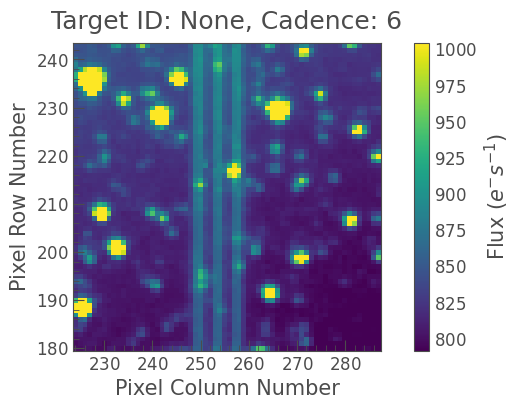

In [75]:
fficut_aster.tpf.plot(frame=6)
plt.show()

###### fficut_aster.quality_mask.shape

In [79]:
fficut_aster.fit_background(polyorder=3, positive_flux=True)

TypeError: fit_background() got an unexpected keyword argument 'vmin'

In [86]:
np.percentile(fficut_aster.flux_2d[0], [0,1,3,50,97,99,100])

array([4.60990524e+00, 1.19722614e+01, 1.52463215e+01, 4.74788208e+01,
       1.92800510e+02, 5.44586279e+02, 1.12887119e+04])

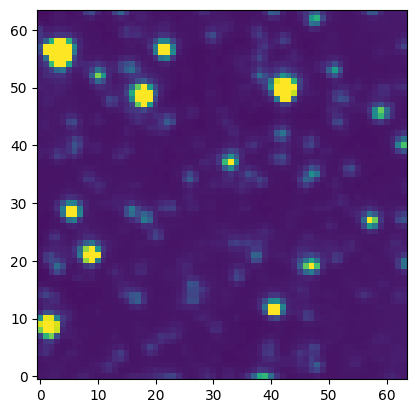

In [92]:
plt.imshow(fficut_aster.flux_2d[1000], origin="lower", vmin=30, vmax=400)
plt.show()

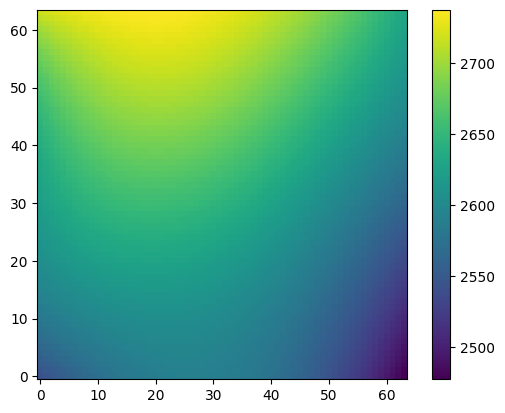

In [83]:
cbar = plt.imshow(fficut_aster.bkg_model[0], origin="lower")
plt.colorbar(cbar)
plt.show()

In [93]:
from scipy.sparse import csr_matrix, hstack, lil_matrix, vstack

In [94]:
cutout_size = 64

e = lil_matrix((cutout_size, cutout_size * cutout_size))
for idx in range(cutout_size):
    e[idx, np.arange(cutout_size) * cutout_size + idx] = 1

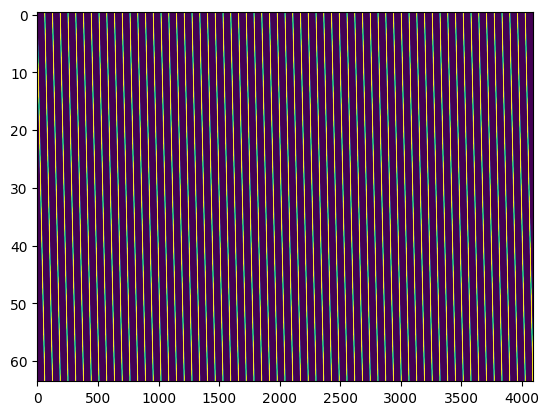

In [104]:
plt.imshow(e.todense(), aspect="auto", vmin=0, vmax=0.1)
plt.show()